In [2]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import seaborn as sns
from programmable_cubes_UDP import ProgrammableCubes
from programmable_cubes_UDP import programmable_cubes_UDP
import numpy as np
from pygmo import problem

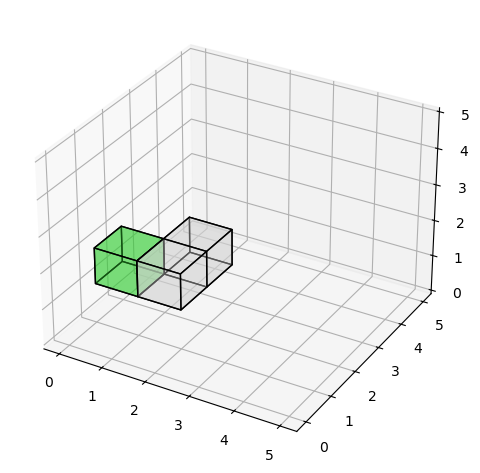

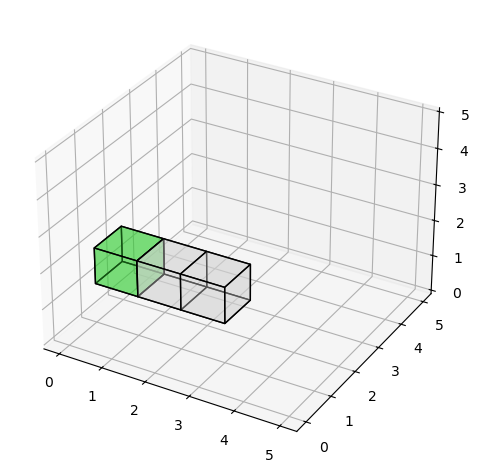

In [3]:


udp = programmable_cubes_UDP("test")
prob = problem(udp)
udp.fitness(np.array([-1]))
ti = udp.initial_cube_types
ci = udp.final_cube_positions
ct = udp.target_cube_positions
tt = udp.target_cube_types

udp.plot("none",cube_type_to_plot=[0,1],custom_config=udp.target_cube_positions,custom_cube_types=udp.target_cube_types)
udp.plot("none",cube_type_to_plot=[0,1],custom_config=udp.final_cube_positions,custom_cube_types=udp.initial_cube_types)

def plot(c,t):
    udp.plot("none",cube_type_to_plot=[0,1],custom_config=c,custom_cube_types=t)



cubes = ProgrammableCubes(ci)



In [4]:




print(np.sum(ci == ct,axis=1) == 3)

[ True False  True]


## Experiments to understand intesection and wrong cubes

In [5]:

def contains_coord(arr, coord):
    for id,c in enumerate(arr):
        if np.sum(c==coord) == len(coord):
            return id
    return -1



# Get the wrong ones
print(ci.shape)
print(ct.shape)
all = np.concat([ci,ct])
print(all.shape)
# This finds coordinates of cubes which are not in their place or empty target place(IGNORES types)
arr, uniq_cnt = np.unique(all, axis=0, return_counts=True)
wrong = arr[uniq_cnt==1]
print(wrong)
# Find empty target place ids:
wrong_ci_ids = []
for coord in wrong:
    id = contains_coord(ci,coord) 
    if id != -1:
        wrong_ci_ids.append(id)
wrong_ci_ids = np.array(wrong_ci_ids)
print(wrong_ci_ids)

# Find empty target place ids:
wrong_ct_ids = []
for coord in wrong:
    id = contains_coord(ct,coord) 
    if id != -1:
        wrong_ct_ids.append(id)
wrong_ct_ids = np.array(wrong_ct_ids)
print(wrong_ct_ids)

(3, 3)
(3, 3)
(6, 3)
[[0 1 0]
 [1 0 0]]
[1]
[1]


## Intersection and difference implementation for algorithm

In [6]:
def get_wrong_cube_ids(arr1,arr2):
    """
    
    """
    arr, cnt = np.unique(np.concat([arr1,arr2]), axis=0, return_counts=True)
    wrong = arr[cnt==1]
    arr1_ids = []
    for coord in wrong:
        id = contains_coord(arr1,coord) 
        if id != -1:
            arr1_ids.append(id)
    arr1_ids = np.array(arr1_ids)

    arr2_ids = []
    for coord in wrong:
        id = contains_coord(arr2,coord) 
        if id != -1:
            arr2_ids.append(id)
    arr2_ids = np.array(arr2_ids)

    return arr1_ids,arr2_ids

print(get_wrong_cube_ids(ci,ct))

(array([1]), array([1]))


## Finding path from coord to coord

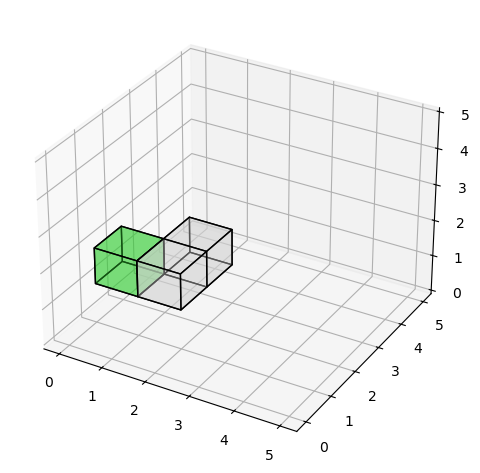

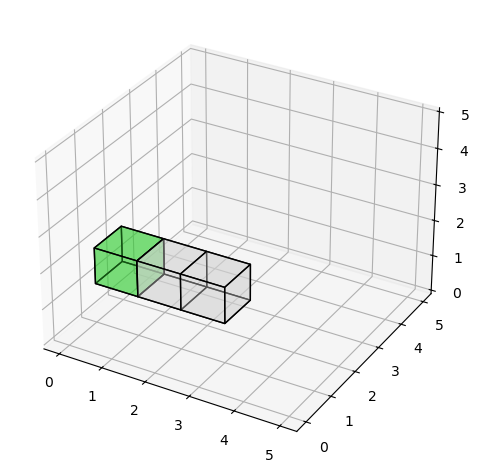

[-1  1  0] [0 1 0]
[-1  1  0] [0 1 0]
[-1  1  0] [0 1 0]
[-1  1  0] [0 1 0]
[0 1 0] [0 1 0]
10
[np.int64(1), 0, np.int64(1), 5, np.int64(1), 4, np.int64(1), 4, np.int64(1), 1]


In [20]:
wi,wt = get_wrong_cube_ids(ci,ct)
# Pick 1 coord of wrong cube and 1 coord of empty target
c1 = ci[wi[0]]
c2 = ct[wt[0]]

# Find the path
alg = []
plot(ct,tt)
plot(ci,ti)
while np.sum(c1 == c2) != 3 and len(alg) < 100:
    rot = np.random.randint(0,6)
    out = cubes.apply_single_update_step(wi[0],rot)
    c1 = cubes.cube_position[wi[0]]
    print(c1,c2)
    alg.append(wi[0])
    alg.append(rot)
    
    #plot(cubes.cube_position,ti)

print(len(alg))
print(alg)

[ 1  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1]
[-0.99705882]


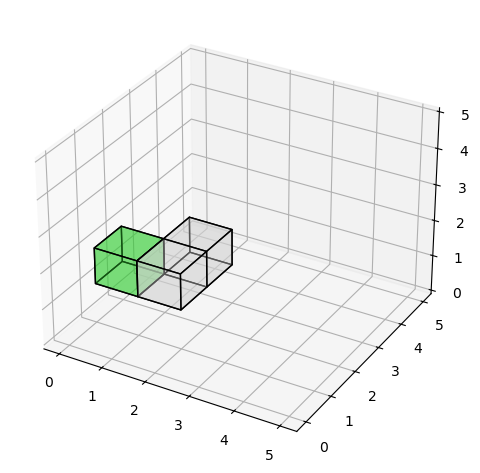

In [25]:

chrom = alg.copy()
chrom = [1,0]
chrom = np.array(chrom)
def remove_illegal_moves_from_chromosome(chromosome):
    """ From tutorial 1"""
    cubes = ProgrammableCubes(ci)

    filtered_chromosome = []

    for i in range(int(len(chromosome)/2)):
        cube_id = chromosome[i*2]
        move = chromosome[i*2+1]
        done = cubes.apply_single_update_step(cube_id, move)
        # done is 1 if the move is legal and 0 otherwise
        if done == 1:
            filtered_chromosome += [cube_id, move]
    # The part to be evaluated by the fitness function ends here,
    # thus we add -1
    filtered_chromosome += [-1]
    
    # Fill up the remaining chromosome with 0s (will not be evaluated)
    if len(filtered_chromosome) < udp.get_nix():
        for i in range(udp.get_nix() - 1 - len(filtered_chromosome)):
            filtered_chromosome += [0]
        # Mandatory entry of -1 at the very end
        filtered_chromosome += [-1]
        
    return np.array(filtered_chromosome)
chrom = remove_illegal_moves_from_chromosome(chrom)
print(chrom)
print(prob.fitness(chrom))
udp.plot("ensemble",[0,1])


[np.float64(-0.1176470588235292)]